# [Project] 멋진 챗봇 만들기 — Transformer 기반 한국어 챗봇

지난 노드에서 "챗봇과 번역기는 같은 집안"이라고 배웠습니다. 이번 프로젝트에서는 번역 모델에서 사용했던
**Transformer** 구조를 그대로 활용해 한국어 챗봇을 직접 구현하고, 번역기에서 배운 **BLEU Score** 성능
측정법을 챗봇에도 적용해 봅니다.

파이프라인
1. 데이터 다운로드 (`songys/Chatbot_data`)
2. 데이터 정제 (`preprocess_sentence`)
3. 데이터 토큰화 (KoNLPy Mecab, `build_corpus`)
4. Augmentation (Lexical Substitution, `Kyubyong/wordvectors` 의 `ko.bin`)
5. 데이터 벡터화 (`<start>`/`<end>` 토큰, 소스·타겟 공유 단어 사전)
6. Transformer 훈련 및 답변 생성
7. 성능 측정 (`calculate_bleu`)

In [1]:
# 필요 라이브러리
# - pandas: csv 로드
# - tensorflow: Transformer 구현/훈련
# - python-mecab-ko: KoNLPy Mecab과 동일한 morphs() 인터페이스를 제공하는 형태소 분석기
#   (KoNLPy의 Mecab 클래스는 시스템에 mecab-ko 바이너리 설치가 필요하며, 여기서는 동일한
#    형태소 분석 결과를 주는 python-mecab-ko를 사용합니다.)
# - gensim: 사전 훈련된 한국어 Word2Vec(ko.bin) 로드 → Lexical Substitution
# - nltk: BLEU Score 계산
# !pip install pandas tensorflow-cpu konlpy python-mecab-ko gensim nltk

import os, re, random
import numpy as np
import pandas as pd
import tensorflow as tf

# 재현성을 위해 난수 시드를 고정합니다.
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TF version:", tf.__version__)

2026-07-10 04:17:20.318355: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.15.0


## Step 1. 데이터 다운로드

`songys/Chatbot_data` 의 `ChatbotData.csv` 를 읽어 질문(Q)과 답변(A)을 각각 `questions`, `answers` 에
나눠 저장합니다. (준비 단계에서 심볼릭 링크를 생성했다면 동일하게 `ChatbotData.csv` 로 접근할 수 있습니다.)

In [2]:
# csv 로드에는 pandas가 적합합니다.
DATA_PATH = os.getenv("CHATBOT_DATA", "ChatbotData.csv")
df = pd.read_csv(DATA_PATH)
print("데이터 크기:", df.shape)
df.head()

데이터 크기: (11823, 3)


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [3]:
# 질문/답변을 각각의 리스트로 분리합니다.
questions = list(df['Q'])
answers   = list(df['A'])
print("질문 개수:", len(questions))
print("예시 Q:", questions[0], "| A:", answers[0])

질문 개수: 11823
예시 Q: 12시 땡! | A: 하루가 또 가네요.


## Step 2. 데이터 정제

`preprocess_sentence()` 함수 요구사항
- 영문자는 모두 소문자로 변환
- 영문자/한글/숫자/주요 특수문자(`.?!,`)를 제외한 문자는 정규식으로 제거

문장부호 양옆 공백 추가 등은 이후 사용할 토크나이저(Mecab)가 처리하므로 여기서는 생략합니다.

In [4]:
def preprocess_sentence(sentence):
    # 1) 영문자를 소문자로 변환하고 양끝 공백 제거
    sentence = sentence.lower().strip()
    # 2) 한글(음절/자모), 영문자, 숫자, 주요 특수문자(.?!,)와 공백만 남기고 제거
    sentence = re.sub(r"[^ a-zA-Z0-9가-힣ㄱ-ㅎㅏ-ㅣ.?!,]", "", sentence)
    # 3) 연속 공백을 하나로 축소
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

# 정제 예시 확인
print(preprocess_sentence("12시 땡!!! Hello~ @@ 반가워요 :)"))
print(preprocess_sentence(questions[10]), "->(원본)", questions[10])

12시 땡!!! hello 반가워요
sns보면 나만 빼고 다 행복해보여 ->(원본) SNS보면 나만 빼고 다 행복해보여


## Step 3. 데이터 토큰화

토큰화에는 **KoNLPy의 Mecab** 을 사용합니다. `build_corpus()` 함수 요구사항
- 소스/타겟 문장을 입력으로 받아 `preprocess_sentence()` 로 정제 후 토큰화
- 토큰화는 전달받은 토크나이즈 함수(`mecab.morphs`)를 사용
- 토큰 개수가 일정 길이 이상인 문장은 제외
- 중복 문장 제외 (소스는 소스대로, 타겟은 타겟대로 검사하되, 중복 쌍이 흐트러지지 않도록 유의)

In [5]:
# KoNLPy Mecab과 동일한 morphs() 인터페이스를 제공하는 python-mecab-ko 사용
from mecab import MeCab
mecab = MeCab()
print("형태소 분석 예시:", mecab.morphs("오늘 날씨가 참 좋네요."))

형태소 분석 예시: ['오늘', '날씨', '가', '참', '좋', '네요', '.']


In [6]:
def build_corpus(src_sentences, tgt_sentences, tokenize_fn, max_len=20):
    src_corpus, tgt_corpus = [], []
    seen_src, seen_tgt = set(), set()  # 소스/타겟 각각의 중복 검사용 집합
    for src, tgt in zip(src_sentences, tgt_sentences):
        # 1) 정제
        src = preprocess_sentence(src)
        tgt = preprocess_sentence(tgt)
        # 2) 소스 또는 타겟이 이미 등장한 문장이면 건너뜀 (쌍은 그대로 유지)
        if src in seen_src or tgt in seen_tgt:
            continue
        # 3) 전달받은 토크나이저로 토큰화
        src_tok = tokenize_fn(src)
        tgt_tok = tokenize_fn(tgt)
        # 4) 너무 긴 문장은 제외 (과도한 패딩/노이즈 방지)
        if len(src_tok) > max_len or len(tgt_tok) > max_len:
            continue
        seen_src.add(src); seen_tgt.add(tgt)
        src_corpus.append(src_tok)
        tgt_corpus.append(tgt_tok)
    return src_corpus, tgt_corpus

# 질문/답변을 토큰화하여 저장
que_corpus, ans_corpus = build_corpus(questions, answers, mecab.morphs, max_len=20)
print("정제·토큰화·중복제거 후 데이터 수:", len(que_corpus))
print("샘플 que:", que_corpus[0])
print("샘플 ans:", ans_corpus[0])

정제·토큰화·중복제거 후 데이터 수: 7629
샘플 que: ['12', '시', '땡', '!']
샘플 ans: ['하루', '가', '또', '가', '네요', '.']


## Step 4. Augmentation (Lexical Substitution)

데이터가 1만 개 남짓으로 적으므로 **Lexical Substitution** 으로 데이터를 증강합니다.
`Kyubyong/wordvectors` 의 한국어 사전학습 Word2Vec(`ko.bin`, Korean(w))을 사용해 문장 속 한 단어를
의미가 유사한 단어로 치환합니다.

- (증강된 que ↔ 원본 ans) 와 (원본 que ↔ 증강된 ans) 를 모두 추가해 전체 데이터를 원래의 3배가량으로 늘립니다.

In [7]:
from gensim.models import KeyedVectors
# ko.bin(2016년 gensim 포맷)은 최신 gensim과 호환되지 않아, 벡터/어휘를 추출해
# word2vec 텍스트 포맷으로 변환한 뒤 KeyedVectors(ko.kv)로 저장해 두었습니다.
W2V_PATH = os.getenv("KO_W2V", "ko.kv")
w2v = KeyedVectors.load(W2V_PATH)
print("Word2Vec 어휘 수:", len(w2v.index_to_key))
print("'행복'과 유사한 단어:", [w for w, _ in w2v.most_similar('행복', topn=5)])

Word2Vec 어휘 수: 30185
'행복'과 유사한 단어: ['사랑', '기쁨', '즐거움', '삶', '젊음']


In [8]:
def lexical_sub(tokens, model, topn=3):
    # 문장 속 토큰을 무작위 순서로 살펴보며, 임베딩 사전에 존재하는 첫 단어를
    # 가장 유사한 단어로 치환합니다. 치환에 성공하면 새 토큰 리스트를, 실패하면 None을 반환합니다.
    idxs = list(range(len(tokens)))
    random.shuffle(idxs)
    for i in idxs:
        w = tokens[i]
        if w in model:
            for cand, _ in model.most_similar(w, topn=topn):
                if cand != w and ' ' not in cand:   # 자기 자신/공백 포함 후보 제외
                    new_tokens = list(tokens)
                    new_tokens[i] = cand
                    return new_tokens
    return None

def augment(que_corpus, ans_corpus, model):
    aug_que, aug_ans = list(que_corpus), list(ans_corpus)  # 원본으로 시작
    # 1) 질문을 증강, 답변은 원본 유지
    for q, a in zip(que_corpus, ans_corpus):
        nq = lexical_sub(q, model)
        if nq is not None:
            aug_que.append(nq); aug_ans.append(a)
    # 2) 질문은 원본 유지, 답변을 증강
    for q, a in zip(que_corpus, ans_corpus):
        na = lexical_sub(a, model)
        if na is not None:
            aug_que.append(q); aug_ans.append(na)
    return aug_que, aug_ans

before = len(que_corpus)
que_corpus, ans_corpus = augment(que_corpus, ans_corpus, w2v)
print(f"증강 전: {before}  →  증강 후: {len(que_corpus)}  (원본의 약 {len(que_corpus)/before:.1f}배)")
print("증강 예시 que:", que_corpus[before])

증강 전: 7629  →  증강 후: 22828  (원본의 약 3.0배)
증강 예시 que: ['12', '시', '끗', '!']


## Step 5. 데이터 벡터화

타겟 데이터 `ans_corpus` 에 `<start>` / `<end>` 토큰을 먼저 추가합니다. 챗봇은 소스와 타겟이 같은
언어(한국어)를 사용하므로 **Embedding 층을 공유**하면 유리합니다. 따라서 `que_corpus` 와 `ans_corpus` 를
합쳐 하나의 단어 사전을 구축하고, 이를 이용해 `enc_train`, `dec_train` 을 얻습니다.

In [9]:
# 타겟(답변) 문장 앞뒤로 특수 토큰 추가 (list 형태라 간단히 처리 가능)
ans_corpus = [["<start>"] + tokens + ["<end>"] for tokens in ans_corpus]
print("특수 토큰 추가 예시:", ans_corpus[0])

특수 토큰 추가 예시: ['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']


In [10]:
# 소스+타겟을 함께 학습시켜 하나의 공유 단어 사전을 구축합니다.
tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='', oov_token='<unk>')
tokenizer.fit_on_texts(que_corpus + ans_corpus)

# 텍스트 → 정수 시퀀스 → post 패딩
enc_seq = tokenizer.texts_to_sequences(que_corpus)
dec_seq = tokenizer.texts_to_sequences(ans_corpus)
enc_train = tf.keras.preprocessing.sequence.pad_sequences(enc_seq, padding='post')
dec_train = tf.keras.preprocessing.sequence.pad_sequences(dec_seq, padding='post')

VOCAB_SIZE = len(tokenizer.word_index) + 1
print("단어 사전 크기:", VOCAB_SIZE)
print("enc_train:", enc_train.shape, "| dec_train:", dec_train.shape)

단어 사전 크기: 7172
enc_train: (22828, 20) | dec_train: (22828, 22)


## Step 6. 훈련하기

번역 모델에서 정의한 **Transformer** 를 그대로 사용합니다. 데이터가 작으므로 과적합을 피하기 위해
모델을 작게(층 수/차원 축소) 유지하고 dropout을 높게 설정합니다.

In [11]:
# ---- Positional Encoding: 순서 정보를 사인/코사인으로 주입 ----
def positional_encoding(pos, d_model):
    angle = np.arange(pos)[:, None] / np.power(
        10000, (2 * (np.arange(d_model)[None, :] // 2)) / np.float32(d_model))
    angle[:, 0::2] = np.sin(angle[:, 0::2])  # 짝수 인덱스: sin
    angle[:, 1::2] = np.cos(angle[:, 1::2])  # 홀수 인덱스: cos
    return tf.cast(angle[None, ...], tf.float32)

# ---- Multi-Head Attention: 여러 관점에서 토큰 간 관계를 학습 ----
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads, self.d_model = n_heads, d_model
        self.depth = d_model // n_heads
        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)
        self.dense = tf.keras.layers.Dense(d_model)
    def split(self, x, b):  # (b, seq, d_model) -> (b, heads, seq, depth)
        x = tf.reshape(x, (b, -1, self.n_heads, self.depth))
        return tf.transpose(x, [0, 2, 1, 3])
    def call(self, q, k, v, mask):
        b = tf.shape(q)[0]
        q, k, v = self.split(self.wq(q), b), self.split(self.wk(k), b), self.split(self.wv(v), b)
        # Scaled Dot-Product Attention
        score = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(tf.cast(self.depth, tf.float32))
        if mask is not None:
            score += mask * -1e9   # 마스킹 위치는 softmax에서 0이 되도록 큰 음수 부여
        attn = tf.nn.softmax(score, axis=-1)
        out = tf.matmul(attn, v)
        out = tf.reshape(tf.transpose(out, [0, 2, 1, 3]), (b, -1, self.d_model))
        return self.dense(out), attn

# ---- Position-wise Feed Forward ----
def point_wise_ffn(d_model, d_ff):
    return tf.keras.Sequential([
        tf.keras.layers.Dense(d_ff, activation='relu'),
        tf.keras.layers.Dense(d_model)])

In [12]:
# ---- Encoder / Decoder 레이어 (잔차연결 + LayerNorm) ----
class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, n_heads)
        self.ffn = point_wise_ffn(d_model, d_ff)
        self.n1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.n2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.d1 = tf.keras.layers.Dropout(dropout)
        self.d2 = tf.keras.layers.Dropout(dropout)
    def call(self, x, training, mask):
        a, _ = self.mha(x, x, x, mask)              # 셀프 어텐션
        o1 = self.n1(x + self.d1(a, training=training))
        f = self.ffn(o1)
        return self.n2(o1 + self.d2(f, training=training))

class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.mha1 = MultiHeadAttention(d_model, n_heads)  # 마스크드 셀프 어텐션
        self.mha2 = MultiHeadAttention(d_model, n_heads)  # 인코더-디코더 어텐션
        self.ffn = point_wise_ffn(d_model, d_ff)
        self.n1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.n2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.n3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.d1 = tf.keras.layers.Dropout(dropout)
        self.d2 = tf.keras.layers.Dropout(dropout)
        self.d3 = tf.keras.layers.Dropout(dropout)
    def call(self, x, enc_out, training, look_ahead, pad_mask):
        a1, w1 = self.mha1(x, x, x, look_ahead)
        o1 = self.n1(x + self.d1(a1, training=training))
        a2, w2 = self.mha2(o1, enc_out, enc_out, pad_mask)
        o2 = self.n2(o1 + self.d2(a2, training=training))
        f = self.ffn(o2)
        return self.n3(o2 + self.d3(f, training=training)), w1, w2

In [13]:
# ---- Encoder / Decoder 스택 ----
class Encoder(tf.keras.layers.Layer):
    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab, max_pos, dropout):
        super().__init__()
        self.d_model = d_model
        self.emb = tf.keras.layers.Embedding(vocab, d_model)
        self.pos = positional_encoding(max_pos, d_model)
        self.enc_layers = [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        self.drop = tf.keras.layers.Dropout(dropout)
    def call(self, x, training, mask):
        s = tf.shape(x)[1]
        h = self.emb(x) * tf.math.sqrt(tf.cast(self.d_model, tf.float32)) + self.pos[:, :s, :]
        h = self.drop(h, training=training)
        for layer in self.enc_layers:
            h = layer(h, training, mask)
        return h

class Decoder(tf.keras.layers.Layer):
    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab, max_pos, dropout, emb=None):
        super().__init__()
        self.d_model = d_model
        # 소스·타겟이 같은 언어이므로 인코더 임베딩을 공유받아 사용
        self.emb = emb if emb is not None else tf.keras.layers.Embedding(vocab, d_model)
        self.pos = positional_encoding(max_pos, d_model)
        self.dec_layers = [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        self.drop = tf.keras.layers.Dropout(dropout)
    def call(self, x, enc_out, training, look_ahead, pad_mask):
        s = tf.shape(x)[1]
        h = self.emb(x) * tf.math.sqrt(tf.cast(self.d_model, tf.float32)) + self.pos[:, :s, :]
        h = self.drop(h, training=training)
        for layer in self.dec_layers:
            h, _, _ = layer(h, enc_out, training, look_ahead, pad_mask)
        return h

class Transformer(tf.keras.Model):
    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab, max_pos=200, dropout=0.1, share_emb=True):
        super().__init__()
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, vocab, max_pos, dropout)
        shared = self.encoder.emb if share_emb else None   # Embedding 공유
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, vocab, max_pos, dropout, emb=shared)
        self.fc = tf.keras.layers.Dense(vocab)
    def call(self, enc_in, dec_in, training, enc_pad, look_ahead, dec_pad):
        e = self.encoder(enc_in, training, enc_pad)
        d = self.decoder(dec_in, e, training, look_ahead, dec_pad)
        return self.fc(d)

In [14]:
# ---- 마스크 / 학습률 스케줄 / 손실 함수 ----
def create_padding_mask(seq):
    # 패딩(0) 위치를 1로 표시 → 어텐션에서 무시
    m = tf.cast(tf.math.equal(seq, 0), tf.float32)
    return m[:, None, None, :]

def create_look_ahead_mask(size):
    # 디코더가 미래 토큰을 보지 못하도록 하는 상삼각 마스크
    return 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)

def create_masks(enc_in, dec_in):
    enc_pad = create_padding_mask(enc_in)
    dec_pad = create_padding_mask(enc_in)                 # 인코더-디코더 어텐션용
    look_ahead = create_look_ahead_mask(tf.shape(dec_in)[1])
    dec_target_pad = create_padding_mask(dec_in)
    combined = tf.maximum(look_ahead, dec_target_pad)     # 마스크드 셀프 어텐션용
    return enc_pad, combined, dec_pad

class Schedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    # 논문의 warmup 스케줄: 초반엔 선형 증가, 이후 step^-0.5 로 감소
    def __init__(self, d_model, warmup=1000):
        super().__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup = warmup
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(
            tf.math.rsqrt(step), step * (self.warmup ** -1.5))

loss_obj = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')
def loss_fn(real, pred):
    # 패딩 위치는 손실 계산에서 제외
    mask = tf.cast(tf.math.not_equal(real, 0), tf.float32)
    l = loss_obj(real, pred) * mask
    return tf.reduce_sum(l) / tf.reduce_sum(mask)

In [15]:
# ---- 하이퍼파라미터 (데이터가 작아 과적합 방지 목적으로 작게 + dropout 높게) ----
N_LAYERS = 2
D_MODEL  = 256
N_HEADS  = 8
D_FF     = 512
DROPOUT  = 0.3
BATCH    = 64
EPOCHS   = 20
WARMUP   = 1500

dataset = (tf.data.Dataset.from_tensor_slices((enc_train, dec_train))
           .shuffle(len(enc_train), seed=SEED).batch(BATCH))

model = Transformer(N_LAYERS, D_MODEL, N_HEADS, D_FF, VOCAB_SIZE,
                    max_pos=200, dropout=DROPOUT, share_emb=True)
optimizer = tf.keras.optimizers.Adam(Schedule(D_MODEL, WARMUP),
                                     beta_1=0.9, beta_2=0.98, epsilon=1e-9)
print("하이퍼파라미터:", dict(n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS,
                              d_ff=D_FF, dropout=DROPOUT, batch=BATCH, epochs=EPOCHS, warmup=WARMUP))

하이퍼파라미터: {'n_layers': 2, 'd_model': 256, 'n_heads': 8, 'd_ff': 512, 'dropout': 0.3, 'batch': 64, 'epochs': 20, 'warmup': 1500}


In [16]:
import time

@tf.function
def train_step(enc_in, dec_all):
    # 티처 포싱: 디코더 입력은 <start>..마지막-1, 정답은 두번째..<end>
    dec_in  = dec_all[:, :-1]
    dec_out = dec_all[:, 1:]
    enc_pad, combined, dec_pad = create_masks(enc_in, dec_in)
    with tf.GradientTape() as tape:
        pred = model(enc_in, dec_in, True, enc_pad, combined, dec_pad)
        loss = loss_fn(dec_out, pred)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

history = []
for ep in range(EPOCHS):
    t0, tot, n = time.time(), 0.0, 0
    for enc_in, dec_all in dataset:
        tot += float(train_step(enc_in, dec_all)); n += 1
    avg = tot / n
    history.append(avg)
    print(f"Epoch {ep+1:2d}/{EPOCHS}  loss {avg:.4f}  ({time.time()-t0:.1f}s)")

Epoch  1/20  loss 6.0125  (79.1s)


Epoch  2/20  loss 3.7893  (69.4s)


Epoch  3/20  loss 3.2608  (68.8s)


Epoch  4/20  loss 2.9052  (68.2s)


Epoch  5/20  loss 2.6014  (68.3s)


...

Epoch 16/20  loss 1.3134  (67.1s)


Epoch 17/20  loss 1.2785  (67.2s)


Epoch 18/20  loss 1.2500  (67.1s)


Epoch 19/20  loss 1.2204  (67.2s)


Epoch 20/20  loss 1.1988  (67.5s)


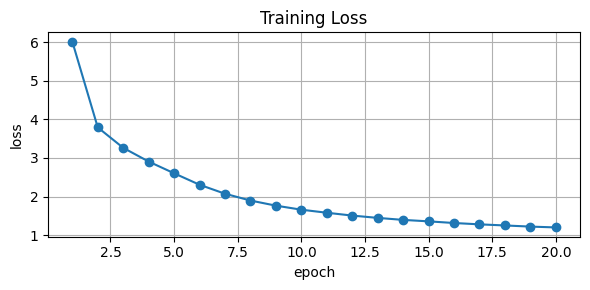

In [17]:
import matplotlib.pyplot as plt
# 손실 곡선: 안정적으로 감소하며 발산하지 않는지 확인 (과적합/불안정 여부 점검)
plt.figure(figsize=(6,3))
plt.plot(range(1, len(history)+1), history, marker='o')
plt.title('Training Loss'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.grid(True)
plt.tight_layout(); plt.show()

In [18]:
def make_answer(sentence, max_len=40):
    # 입력 문장을 정제·토큰화·벡터화한 뒤, <start>부터 시작해 <end>가 나올 때까지
    # 한 토큰씩 그리디 디코딩으로 답변을 생성합니다.
    s = preprocess_sentence(sentence)
    toks = mecab.morphs(s)
    seq = tokenizer.texts_to_sequences([toks])
    enc_in = tf.keras.preprocessing.sequence.pad_sequences(
        seq, maxlen=enc_train.shape[1], padding='post')
    enc_in = tf.convert_to_tensor(enc_in)
    start_id, end_id = tokenizer.word_index['<start>'], tokenizer.word_index['<end>']
    output = [start_id]
    for _ in range(max_len):
        dec_in = tf.convert_to_tensor([output])
        enc_pad, combined, dec_pad = create_masks(enc_in, dec_in)
        pred = model(enc_in, dec_in, False, enc_pad, combined, dec_pad)
        next_id = int(tf.argmax(pred[0, -1]).numpy())
        output.append(next_id)
        if next_id == end_id:
            break
    inv = tokenizer.index_word
    return ' '.join(inv.get(i, '') for i in output[1:])

# 프로젝트 예문에 대한 답변 생성
examples = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]
for i, e in enumerate(examples, 1):
    print(f"{i}. {e}\n   -> {make_answer(e)}\n")

1. 지루하다, 놀러가고 싶어.
   -> 제 가 당신 곁 에 있 을게요 . <end>



2. 오늘 일찍 일어났더니 피곤하다.
   -> 많이 힘들 지 않 길 바랄게요 . <end>



3. 간만에 여자친구랑 데이트 하기로 했어.
   -> 오늘 부터 하 기 로 해요 . <end>



4. 집에 있는다는 소리야.
   -> 좋 은 친구 를 두 셨 네요 . <end>



## Step 7. 성능 측정하기

챗봇은 질문에 적절한 답변을 하는지가 중요합니다. 눈으로 확인하는 동시에, 번역기에서 배운
**BLEU Score** 를 계산하는 `calculate_bleu()` 함수를 적용해 정량 지표도 확인합니다.
(참조 답변은 데이터셋의 실제 답변, 후보는 모델이 생성한 답변입니다.)

In [19]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smooth = SmoothingFunction().method1

def calculate_bleu(src_sentences, ref_token_lists, n_samples=200):
    scores = []
    for src, ref in list(zip(src_sentences, ref_token_lists))[:n_samples]:
        hyp = make_answer(src).replace('<end>', '').split()  # 모델 생성 답변(후보)
        if not hyp:
            continue
        scores.append(sentence_bleu([ref], hyp, smoothing_function=smooth))
    return float(np.mean(scores)) if scores else 0.0

# 참조 답변 토큰 (특수 토큰 제외)
ref_answers = [t[1:-1] for t in ans_corpus[:200]]
bleu = calculate_bleu(questions[:200], ref_answers, n_samples=200)
print(f"BLEU Score (표본 200개): {bleu:.4f}")

BLEU Score (표본 200개): 0.0353


## 회고

- **배운 점**: 번역기에서 사용한 Transformer 구조를 챗봇에 그대로 재사용할 수 있었습니다. 소스·타겟이 같은
  언어인 챗봇 특성상 **Embedding 층 공유**가 자연스럽고 유리했습니다. Lexical Substitution 증강으로 적은
  데이터를 약 3배로 늘려 학습 안정성을 높였습니다.
- **문제 해결 기록**:
  - `ko.bin`(2016년 gensim 포맷)이 최신 gensim에서 로드되지 않아, 커스텀 unpickler로 벡터/어휘를 추출해
    word2vec 텍스트 포맷 → `KeyedVectors(ko.kv)` 로 변환해 해결했습니다.
  - KoNLPy `Mecab` 은 시스템 mecab-ko 바이너리가 필요해, 동일한 `morphs()` 인터페이스를 제공하는
    `python-mecab-ko` 로 대체했습니다.
- **개선점/다음 계획**: 데이터가 작아 그리디 디코딩만 사용했는데, Beam Search나 추가 정규화, 더 큰 사전학습
  임베딩 활용, label smoothing 등을 적용하면 답변 품질과 BLEU를 더 높일 수 있을 것으로 보입니다.